In [65]:
import os
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking

In [77]:
#Configuration
sequence_length = 20
input_features = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Tilt_X', 'Tilt_Y', 'Tilt_Z', 'Mag_X', 'Mag_Y', 'Mag_Z', 'Head', 'Temp', 'Press', 'delta_Alt']
target_features = ['delta_Lat', 'delta_Lng']

train_folder = 'data/train'
test_folder = 'data/test'

In [78]:
# Load and preprocess data from all CSV files in the 'train' folder
def load_data_from_folder(folder_path, seq_length):
    sequences = []
    targets = []
    
    for file in os.listdir(folder_path):
        # Load the CSV file and ignore the first row since its target is (0.0, 0.0)
        data = pd.read_csv(os.path.join(folder_path, file), delimiter=";")
        data = data.iloc[1:]
        
        # Get the input features and the target features (scaled *1000 for better training)
        input_data = data[input_features].values
        target_data = data[target_features].values * 1000
        
        # Consume the data in sequences of seq_length
        for i in range(0, len(input_data), seq_length):
            seq_chunk = input_data[i:i + seq_length]
            target_chunk = target_data[i:i + seq_length]
            
            # If the last chunk is smaller than the seq_length, pad it with zeros
            if len(seq_chunk) < seq_length:
                # If the chunk will contain more padding than real data, skip it
                #if len(seq_chunk) < seq_length // 2:
                    #continue

                padding_input = np.zeros((seq_length - len(seq_chunk), input_data.shape[1]))
                padding_target = np.zeros((seq_length - len(target_chunk), target_data.shape[1]))
                seq_chunk = np.vstack((seq_chunk, padding_input))
                target_chunk = np.vstack((target_chunk, padding_target))
            
            sequences.append(seq_chunk)
            targets.append(target_chunk)

    return np.array(sequences), np.array(targets)

In [79]:
# Load training and test data

X_train, y_train = load_data_from_folder(train_folder, sequence_length)

print(X_train.shape)    
print(y_train.shape)


X_test, y_test = load_data_from_folder(test_folder, sequence_length)

(98, 20, 16)
(98, 20, 2)


In [80]:


# Define the LSTM model
model = Sequential()
model.add(Masking(mask_value=0.0, input_shape=(sequence_length, len(input_features))))
model.add(LSTM(64, input_shape=(sequence_length, len(input_features)), return_sequences=True))
model.add(Dense(32, activation='relu'))
model.add(Dense(2))

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=300, batch_size=32)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")

# Save the trained model
model.save('lstm_delta_gps_model.keras')

Epoch 1/300


c:\Users\Usuario\anaconda3\envs\Quanvia\Lib\site-packages\keras\src\layers\core\masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Usuario\anaconda3\envs\Quanvia\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0608 - val_loss: 0.0093
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0139 - val_loss: 0.0130
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0147 - val_loss: 0.0072
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0120 - val_loss: 0.0075
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0109 - val_loss: 0.0077
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0112 - val_loss: 0.0073
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0105 - val_loss: 0.0067
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0098 - val_loss: 0.0071
Epoch 9/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0103 - val_loss: 0.0068
Epoch 10/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0095 - val_loss: 0.0071
Epoch 11/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0094 - val_loss: 0.0066
Epoch 12/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0098 - val_loss: 0.0070
Epoch 13/300

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


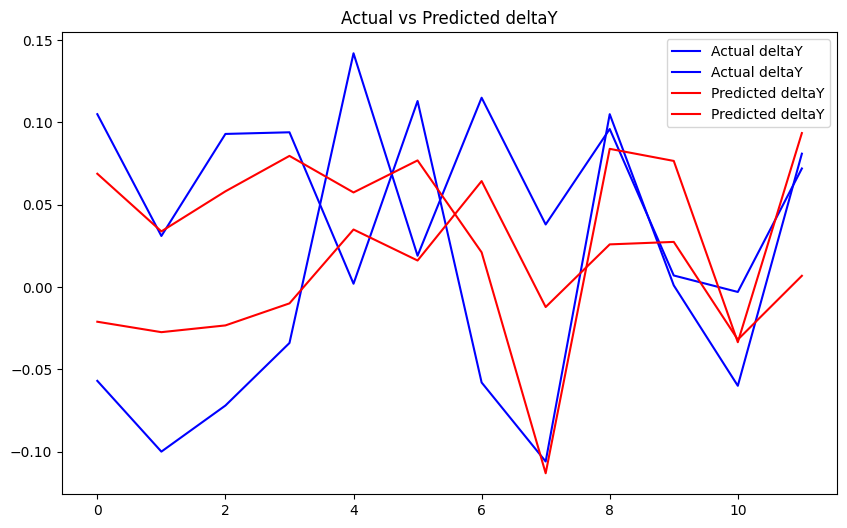

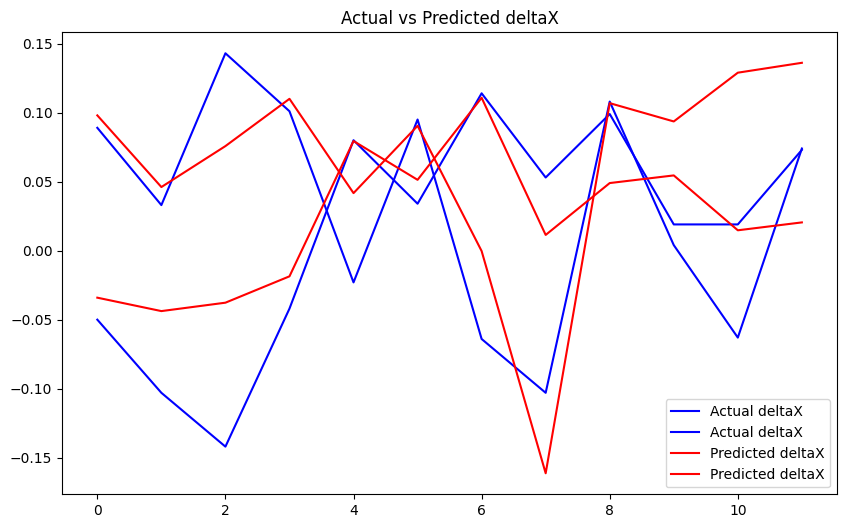

In [81]:
import matplotlib.pyplot as plt

# Make predictions using the model on the test set
y_pred = model.predict(X_test)

# Plot actual vs predicted for deltaY
plt.figure(figsize=(10, 6))
plt.plot(y_test[:, 0], label='Actual deltaY', color='blue')
plt.plot(y_pred[:, 0], label='Predicted deltaY', color='red')
plt.title('Actual vs Predicted deltaY')
plt.legend()
plt.show()

# Plot actual vs predicted for deltaX
plt.figure(figsize=(10, 6))
plt.plot(y_test[:, 1], label='Actual deltaX', color='blue')
plt.plot(y_pred[:, 1], label='Predicted deltaX', color='red')
plt.title('Actual vs Predicted deltaX')
plt.legend()
plt.show()


In [82]:
# Function to calculate real and predicted routes
def calculate_routes(file_path, sequence_length, input_features, model):
    data = pd.read_csv(file_path, delimiter=";")
    
    # Get the first point from 'Lat' and 'Lng'
    lat_real = [data.iloc[0]['Lat']]
    lng_real = [data.iloc[0]['Lng']]
    
    # Initialize real route
    for i in range(1, len(data)):
        # Get the deltas
        delta_lat = data.iloc[i]['delta_Lat']
        delta_lng = data.iloc[i]['delta_Lng']
        
        # Calculate next point based on the previous one
        lat_real.append(lat_real[-1] + delta_lat)
        lng_real.append(lng_real[-1] + delta_lng)
    
    # Now calculate the predicted route
    lat_pred = [data.iloc[0]['Lat']]
    lng_pred = [data.iloc[0]['Lng']]
    
    # Extract input data
    input_data = data[input_features].values
    
    # Predict deltas and accumulate to form the predicted route
    for i in range(1, len(data)):
        # Prepare sequence for prediction
        if i >= sequence_length:
            X_test = input_data[i-sequence_length:i].reshape(1, sequence_length, len(input_features))
        else:
            # For first few rows, pad with zeros if needed (or handle edge case)
            X_test = np.pad(input_data[:i], ((sequence_length-i, 0), (0, 0)), mode='constant').reshape(1, sequence_length, len(input_features))
        
        # Predict deltas
        delta_lat_pred, delta_lng_pred = model.predict(X_test)[0] / 1000
        
        # Calculate next predicted point
        lat_pred.append(lat_pred[-1] + delta_lat_pred)
        lng_pred.append(lng_pred[-1] + delta_lng_pred)
    
    return lat_real, lng_real, lat_pred, lng_pred

# Function to plot real and predicted routes for each test file
def plot_routes(test_folder, sequence_length, input_features, model):
    test_files = [f for f in os.listdir(test_folder) if f.endswith('.csv')]
    num_files = len(test_files)
    
    fig, axes = plt.subplots(nrows=num_files, ncols=1, figsize=(8, num_files * 6))
    
    if num_files == 1:
        axes = [axes]  #Ensure axes is iterable if there's only one file
    
    for idx, test_file in enumerate(test_files):
        file_path = os.path.join(test_folder, test_file)
        
        lat_real, lng_real, lat_pred, lng_pred = calculate_routes(file_path, sequence_length, input_features, model)
        
        # Plot real and predicted points
        axes[idx].plot(lng_real, lat_real, color='blue', label='Real Route', marker='o', markersize=5)
        axes[idx].plot(lng_pred, lat_pred, color='red', label='Predicted Route', marker='o', markersize=5)
        
        axes[idx].set_title(f'Test File: {test_file}')
        axes[idx].set_xlabel('Lng')
        axes[idx].set_ylabel('Lat')
        axes[idx].legend()
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


ValueError: too many values to unpack (expected 2)

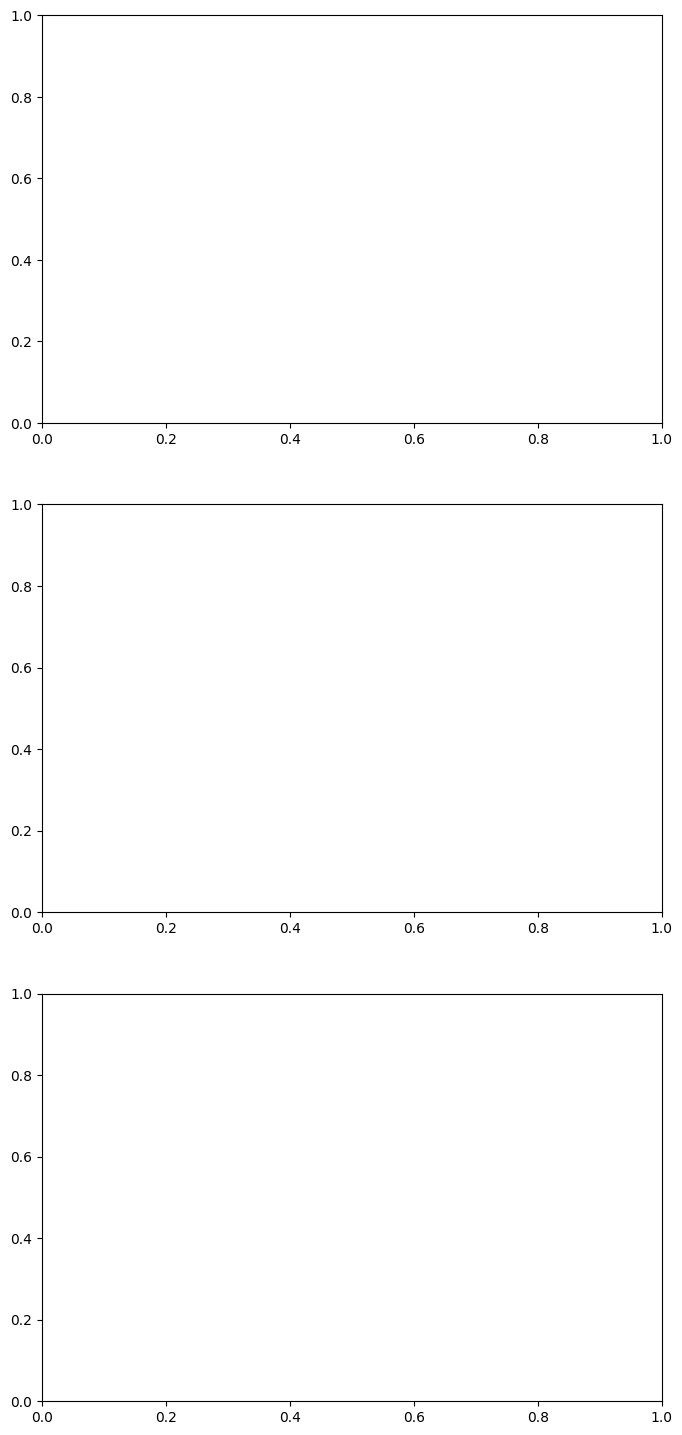

In [83]:
plot_routes(test_folder, sequence_length, input_features, model)